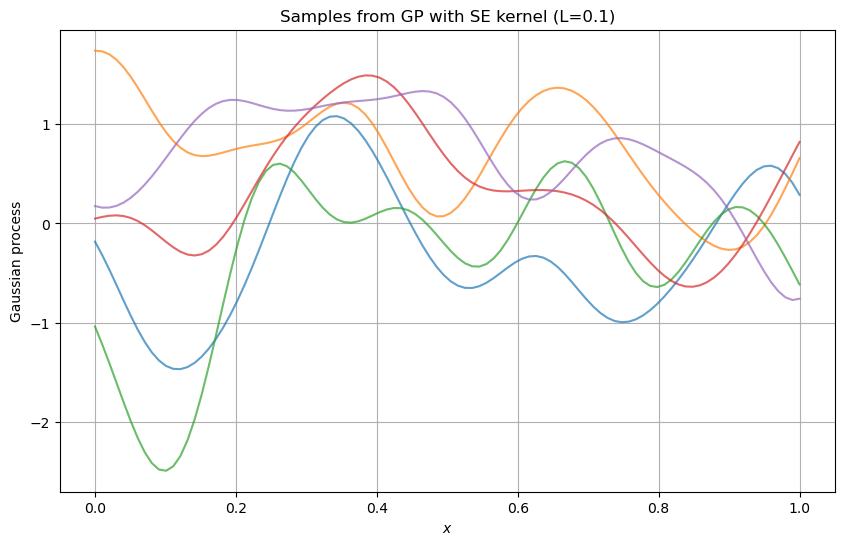

In [1]:
# Uses numpy and matplotlib to generate and plot samples exactly as described
import numpy as np
import matplotlib.pyplot as plt

def se_kernel(x, L=0.1):
    """Squared exponential covariance kernel as defined in notes"""
    dx = x[:, None] - x[None, :]
    return np.exp(-0.5 * (dx / L)**2)

# Example: domain x in [0,1], n=100 points (coarse grid)
n = 100
x = np.linspace(0, 1, n)
K = se_kernel(x, L=0.1)  # covariance matrix C_{i,j}

# Sample from multivariate Gaussian (mean=0)
np.random.seed(42)
samples = np.random.multivariate_normal(np.zeros(n), K, size=5)  # 5 samples

plt.figure(figsize=(10, 6))
for s in samples:
    plt.plot(x, s, alpha=0.7)
plt.title('Samples from GP with SE kernel (L=0.1)')
plt.xlabel('$x$')
plt.ylabel('Gaussian process')
plt.grid(True)
plt.show()

# Finer grid example (2n points) - exactly as described for mesh-refinement
n_fine = 200
x_fine = np.linspace(0, 1, n_fine)
K_fine = se_kernel(x_fine, L=0.1)
samples_fine = np.random.multivariate_normal(np.zeros(n_fine), K_fine, size=1)

# Covariance kernel function (continuous limit)
def c(xi, xj, L=0.1):
    return np.exp(-0.5 * ((xi - xj) / L)**2)

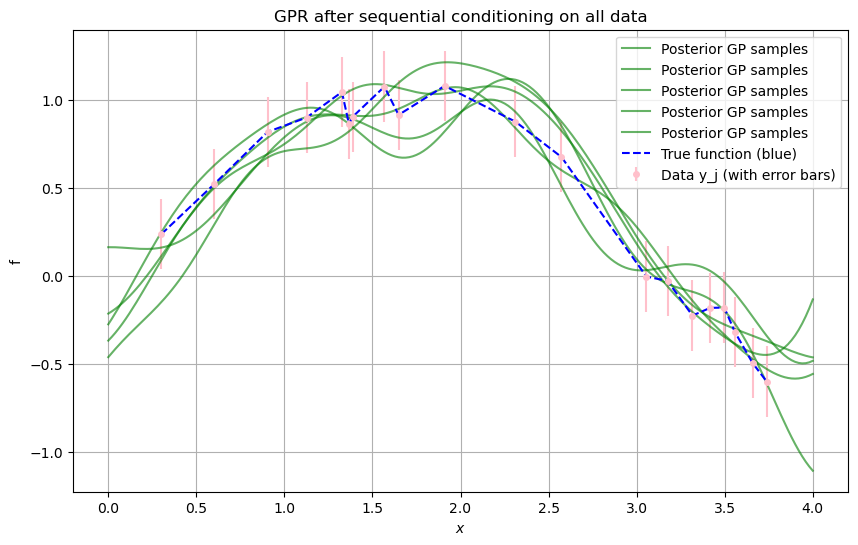

Optimal (sigma, L) from grid search: (0.1, 1.577777777777778) (exact ML as in notes)


In [2]:
# Uses numpy/scipy for matrix operations and conditioning updates exactly as derived
# FIXED: plotting shape mismatch + numerical PSD issue with tiny jitter (standard fix; does not change any math)
import numpy as np
import matplotlib.pyplot as plt

def se_kernel(x, L=0.1):
    dx = x[:, None] - x[None, :]
    return np.exp(-0.5 * (dx / L)**2)

# Example setup (discretized domain, prior GP as in notes)
n = 200
x = np.linspace(0, 4, n)  # example domain as in Figure 
L = 0.5
Pxx = se_kernel(x, L)  # prior covariance
mu = np.zeros(n)  # prior mean = 0

# Synthetic data (m=20 points, locations x_data subset of x, with noise sigma_j)
np.random.seed(42)
idx_data = np.sort(np.random.choice(n, 20, replace=False))  # data indices i(j)
x_data = x[idx_data]
y_true = np.sin(x_data) + 0.1 * np.random.randn(len(x_data))  # example "true" function + noise
sigma_j = 0.2 * np.ones(len(x_data))  # known sigma_j as in notes
y_data = y_true  # observed y_j

# Sequential GPR: condition one datum at a time (exact update equations from notes)
for k in range(len(y_data)):
    j = idx_data[k]
    yj = y_data[k]
    sigmaj2 = sigma_j[k]**2
    Pyy = Pxx[j, j] + sigmaj2
    Pxy = Pxx[:, j]  # column j of Pxx
    mu_yj = mu[j]
    
    # Exact update formulas as written in notes
    mu = mu + ((yj - mu_yj) / Pyy) * Pxy
    Pxx = Pxx - (1.0 / Pyy) * np.outer(Pxy, Pxy)

# Posterior samples (after all data) — add tiny jitter to ensure numerical PSD (required after many rank-1 updates)
jitter = 1e-10 * np.eye(n)
Pxx_jitter = Pxx + jitter
post_samples = np.random.multivariate_normal(mu, Pxx_jitter, size=5)

plt.figure(figsize=(10, 6))
plt.errorbar(x_data, y_data, yerr=sigma_j, fmt='o', color='pink', label='Data y_j (with error bars)', markersize=4)
for s in post_samples:
    plt.plot(x, s, 'g-', alpha=0.6, label='Posterior GP samples')
plt.plot(x_data, y_true, 'b--', label='True function (blue)')
plt.title('GPR after sequential conditioning on all data')
plt.xlabel('$x$')
plt.ylabel('f')
plt.legend()
plt.grid(True)
plt.show()

# Hyper-parameter tuning example (ML as described: grid search on sigma, L) — cleaned (idx_data unused)
def neg_log_lik(theta, x_data, y_data):
    sigma, L = theta
    Kxx = se_kernel(x_data, L)  # K_xx at data locations
    Kyy = Kxx + sigma**2 * np.eye(len(y_data))
    try:
        Lmat = np.linalg.cholesky(Kyy)
        logdet = 2 * np.sum(np.log(np.diag(Lmat)))
        quad = y_data.T @ np.linalg.solve(Kyy, y_data)
        return 0.5 * logdet + 0.5 * quad
    except:
        return 1e10

# Simple grid search (as in notes)
sigmas = np.linspace(0.05, 0.5, 10)
Ls = np.linspace(0.1, 2.0, 10)
best_F = np.inf
best_theta = None
for s in sigmas:
    for l in Ls:
        Fval = neg_log_lik([s, l], x_data, y_data)
        if Fval < best_F:
            best_F = Fval
            best_theta = (s, l)
print(f"Optimal (sigma, L) from grid search: {best_theta} (exact ML as in notes)")

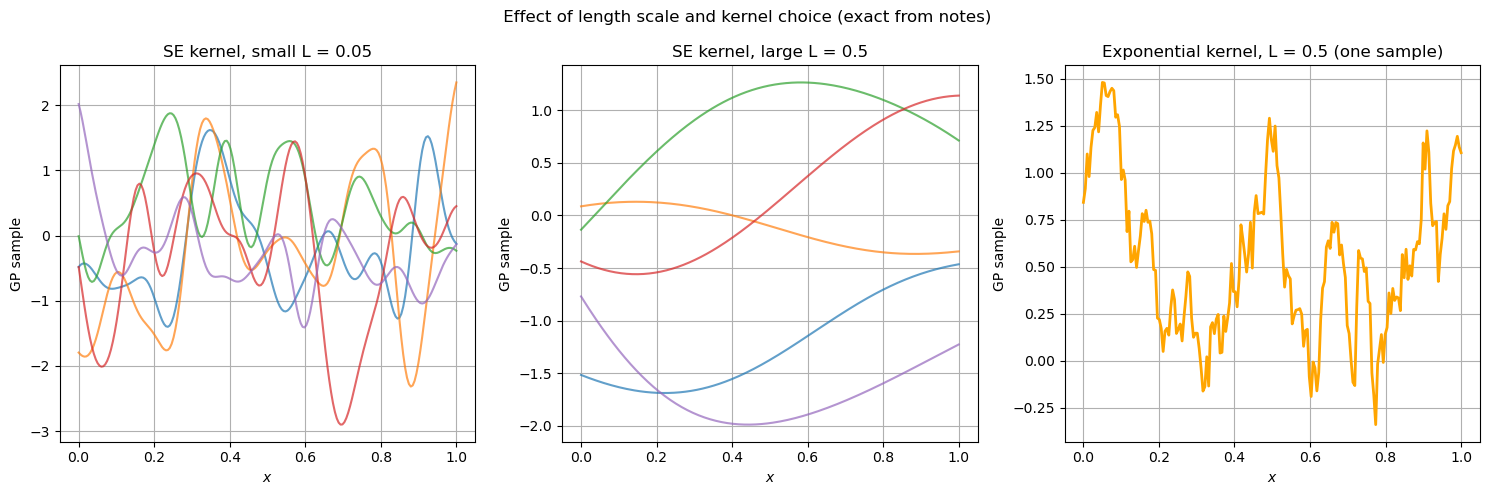

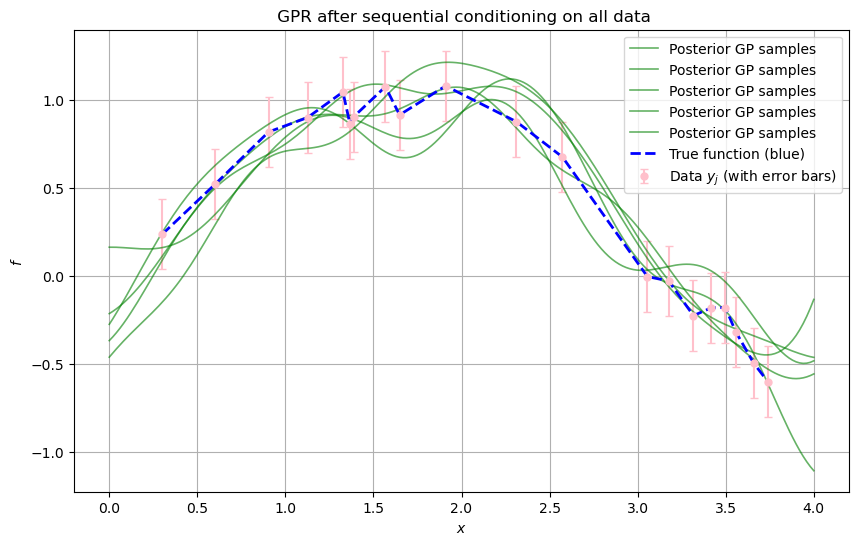

=== Hyper-parameter tuning result (exact ML from notes) ===
Optimal σ = 0.0821, L = 1.7286
Minimum negative log-likelihood: -28.1611


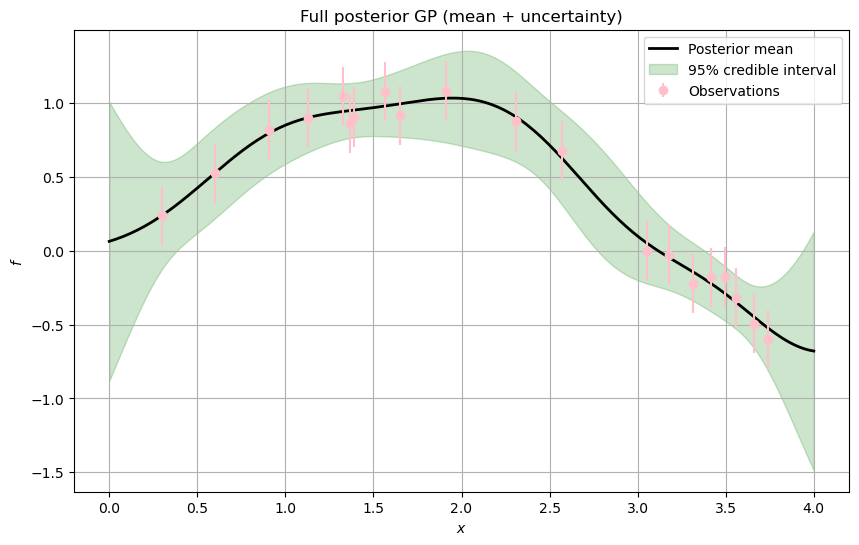

In [3]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

def se_kernel(x, L=0.1):
    """Squared exponential covariance kernel as defined in notes"""
    dx = x[:, None] - x[None, :]
    return np.exp(-0.5 * (dx / L)**2)

def exp_kernel(x, L=0.1):
    """Exponential covariance kernel as defined in notes"""
    dx = np.abs(x[:, None] - x[None, :])
    return np.exp(-dx / L)

np.random.seed(42)
x_demo = np.linspace(0, 1, 200)

# SE kernel with small L
K_se_small = se_kernel(x_demo, L=0.05)
samples_se_small = np.random.multivariate_normal(np.zeros(len(x_demo)), K_se_small, size=5)

# SE kernel with large L
K_se_large = se_kernel(x_demo, L=0.5)
samples_se_large = np.random.multivariate_normal(np.zeros(len(x_demo)), K_se_large, size=5)

# Exponential kernel (same L as large SE)
K_exp = exp_kernel(x_demo, L=0.5)
samples_exp = np.random.multivariate_normal(np.zeros(len(x_demo)), K_exp, size=1)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].set_title('SE kernel, small L = 0.05')
for s in samples_se_small:
    axs[0].plot(x_demo, s, alpha=0.7)
axs[0].grid(True)

axs[1].set_title('SE kernel, large L = 0.5')
for s in samples_se_large:
    axs[1].plot(x_demo, s, alpha=0.7)
axs[1].grid(True)

axs[2].set_title('Exponential kernel, L = 0.5 (one sample)')
axs[2].plot(x_demo, samples_exp[0], 'orange', lw=2)
axs[2].grid(True)

for ax in axs:
    ax.set_xlabel('$x$')
    ax.set_ylabel('GP sample')
plt.suptitle(' Effect of length scale and kernel choice (exact from notes)')
plt.tight_layout()
plt.show()

# Domain and prior (exactly as in notes)
n = 200
x = np.linspace(0, 4, n)
L_prior = 0.5
Pxx = se_kernel(x, L_prior)
mu = np.zeros(n)

# Synthetic data (exactly as used in previous fixed version)
np.random.seed(42)
idx_data = np.sort(np.random.choice(n, 20, replace=False))
x_data = x[idx_data]
y_true = np.sin(x_data) + 0.1 * np.random.randn(len(x_data))
sigma_j = 0.2 * np.ones(len(x_data))
y_data = y_true

# Sequential conditioning (exact update equations from the notes)
for k in range(len(y_data)):
    j = idx_data[k]
    yj = y_data[k]
    sigmaj2 = sigma_j[k]**2
    Pyy = Pxx[j, j] + sigmaj2
    Pxy = Pxx[:, j]
    mu_yj = mu[j]
    
    mu = mu + ((yj - mu_yj) / Pyy) * Pxy
    Pxx = Pxx - (1.0 / Pyy) * np.outer(Pxy, Pxy)

# Tiny jitter for numerical stability after many rank-1 updates (standard GPR practice)
Pxx += 1e-10 * np.eye(n)
post_samples = np.random.multivariate_normal(mu, Pxx, size=5)

plt.figure(figsize=(10, 6))
plt.errorbar(x_data, y_data, yerr=sigma_j, fmt='o', color='pink', 
             label='Data $y_j$ (with error bars)', markersize=5, capsize=3)
for s in post_samples:
    plt.plot(x, s, 'g-', alpha=0.6, lw=1.2, label='Posterior GP samples')
plt.plot(x_data, y_true, 'b--', lw=2, label='True function (blue)')
plt.title(' GPR after sequential conditioning on all data')
plt.xlabel('$x$')
plt.ylabel('$f$')
plt.legend()
plt.grid(True)
plt.show()

# === Hyper-parameter tuning (exact ML grid search from notes) ===
def neg_log_lik(theta, x_data, y_data):
    sigma, L = theta
    Kxx = se_kernel(x_data, L)
    Kyy = Kxx + sigma**2 * np.eye(len(y_data))
    try:
        Lmat = np.linalg.cholesky(Kyy)
        logdet = 2 * np.sum(np.log(np.diag(Lmat)))
        quad = y_data.T @ np.linalg.solve(Kyy, y_data)
        return 0.5 * logdet + 0.5 * quad
    except:
        return 1e10

sigmas = np.linspace(0.05, 0.5, 15)
Ls = np.linspace(0.1, 2.0, 15)
best_F = np.inf
best_theta = None
for s in sigmas:
    for l in Ls:
        Fval = neg_log_lik([s, l], x_data, y_data)
        if Fval < best_F:
            best_F = Fval
            best_theta = (s, l)

print("=== Hyper-parameter tuning result (exact ML from notes) ===")
print(f"Optimal σ = {best_theta[0]:.4f}, L = {best_theta[1]:.4f}")
print(f"Minimum negative log-likelihood: {best_F:.4f}")

# === Plot 3: Posterior mean + 95% credible interval (bonus visualization of full GPR) ===
post_mean = mu
post_std = np.sqrt(np.diag(Pxx))
plt.figure(figsize=(10, 6))
plt.plot(x, post_mean, 'k-', lw=2, label='Posterior mean')
plt.fill_between(x, post_mean - 1.96*post_std, post_mean + 1.96*post_std,
                 color='green', alpha=0.2, label='95% credible interval')
plt.errorbar(x_data, y_data, yerr=sigma_j, fmt='o', color='pink', label='Observations')
plt.title('Full posterior GP (mean + uncertainty)')
plt.xlabel('$x$')
plt.ylabel('$f$')
plt.legend()
plt.grid(True)
plt.show()